In [1]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import Results

/bin/bash: /home/users/vb97/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /home/users/vb97/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [2]:
with open(f'all_datasets_results.pkl', 'rb') as f:
    all_datasets_results = pickle.load(f)

In [3]:
dn = "diabetes"
df = all_datasets_results[dn]
for i, row in df.iterrows():
    w_rset = row['w_rset']
    w_opt = row['w_opt']
    l0 = row['l0']
    l2 = row['l2']
    method_type = row['method_type']

    dataset = Results.load_dataset(f"../results/{dn}", {'l0': l0, 'l2': l2})
    bin_X = dataset['bin_X']
    cum_X = dataset['cum_X']
    y = dataset['y']
    bin_header = dataset['bin_header']
    cum_header = dataset['cum_header']

    bin_header_object = ModelUtils.get_header_object(bin_header)
    cum_header_object = ModelUtils.get_header_object(cum_header)
    feature_indices = ModelUtils.get_feature_indices(bin_header)
    feature_widths = ModelUtils.get_feature_widths(bin_header)

    print(f"bin_header_object: {bin_header_object}")
    print("\t", sum(len(v) for v in bin_header_object.values()))
    print(f"cum_header_object: {cum_header_object}")
    print("\t", sum(len(v) for v in cum_header_object.values()))
    print(f"feature_indices: {feature_indices}")
    print("\t", sum(len(v) for v in feature_indices.values()))
    print(f"feature_widths: {feature_widths}")
    print("\t", sum(len(v) for v in feature_widths.values()))

    print(len(bin_header), w_rset.shape)
    break

loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
bin_header_object: defaultdict(<class 'list'>, {'intercept': [], 'Pregnancies': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 17.0], 'Glucose': [0.0, 44.0, 56.0, 57.0, 61.0, 62.0, 65.0, 67.0, 68.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 150.0, 151.0, 152.0, 153.0, 154.0, 155.0, 156.0, 157.0, 158.0, 159.0, 160.0, 161.0, 162.0, 163.0, 164.0, 165.0, 166.0, 167.0, 168.0, 169.0, 170.0, 171.0, 172.0, 173.0, 174.0,

In [6]:
for f, thresholds in bin_header_object.items():
    print(f, len(thresholds))


intercept 0
Pregnancies 17
Glucose 136
BloodPressure 47
SkinThickness 51
Insulin 186
BMI 248
DiabetesPedigreeFunction 517
Age 52


In [1]:
import mcmc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
print(torch.cuda.is_available())
import pickle as pkl

dataset = pd.read_csv('/usr/xtmp/vb97/FRL_Rashomon_Set/falling-models/data/benchmark/compas.csv')


/bin/bash: /home/users/vb97/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /home/users/vb97/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


True


In [2]:
mcmc_method = mcmc.MCMCMethod()
out = mcmc_method.run_dataset(dn = 'compas', l0=0.001, l2=0.001, eps=0.01, ne=20, n_support_set=30, proposal_function='random', sigma2=10.0, r_min=None, sample_from_rset=0, beta=1.0, mh_variant='standard', full_refit_interval=10, cd_steps_on_proposal=10)
with open('results_compas_mcmc.pkl', 'wb') as f:
    pkl.dump(out, f)
with open('results_compas_mcmc.pkl', 'rb') as f:
    out = pkl.load(f)


loading dataset from results/compas/l0_0.001_l2_0.001.pkl
Loading cached fastsparse dataset for compas with l0=0.001 and l2=0.001
fitting optimal model
X_new_normalized shape: (6907, 13)
y shape: (6907,)
lamb: 0.002
H shape: (13, 13)
multiplier: 1.01
saving model to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
model saved to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
fitting ellipsoid
fitted ellipsoid
time taken to fit optimal model: 5.009135723114014
MCMC sampling...
random sampling...
step 5, |S|=10, J=-4668.49
step 10, |S|=11, J=-4438.84
step 15, |S|=11, J=-4439.44
step 20, |S|=11, J=-4464.90
step 25, |S|=11, J=-4701.18
step 30, |S|=11, J=-4362.16
step 35, |S|=11, J=-4593.54
step 40, |S|=11, J=-4427.40
step 45, |S|=11, J=-4694.45
step 50, |S|=11, J=-4426.30


 ... (more hidden) ...

X_new_normalized shape: (6907, 15)
y shape: (6907,)
lamb: 0.002
H shape: (15, 15)
multiplier: 1.01
saving model to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
model saved to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
fitting ellipsoid


 ... (more hidden) ...

fitted ellipsoid
X_new_normalized shape: (6907, 14)
y shape: (6907,)
lamb: 0.002
H shape: (14, 14)
multiplier: 1.01
saving model to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
model saved to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
fitting ellipsoid


 ... (more hidden) ...

fitted ellipsoid
X_new_normalized shape: (6907, 15)
y shape: (6907,)
lamb: 0.002
H shape: (15, 15)
multiplier: 1.01
saving model to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p
model saved to: /usr/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/models/compas_0.001_0.001_1.01.p


 ... (more hidden) ...

fitting ellipsoid


_LinAlgError: torch.linalg.solve: The solver failed because the input matrix is singular.

loading dataset from results/compas/l0_0.01_l2_0.01.pkl
Loading cached fastsparse dataset for compas with l0=0.01 and l2=0.01


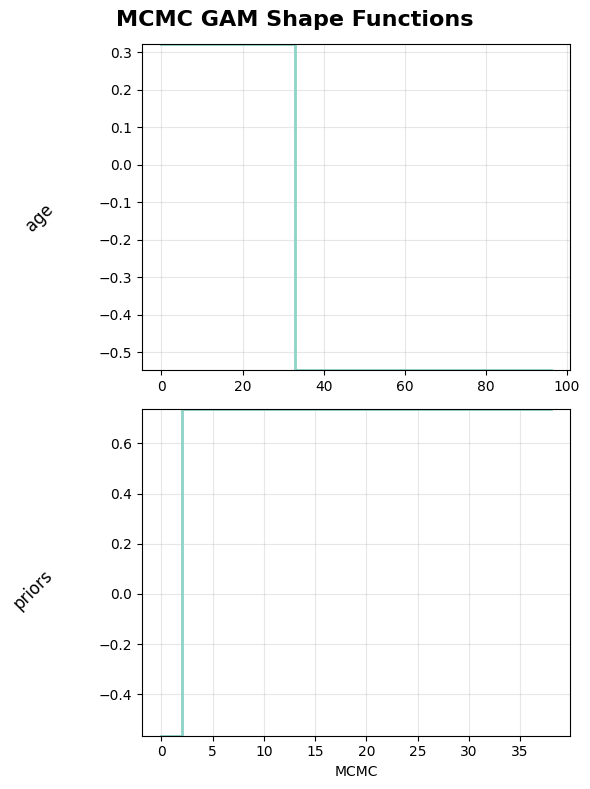

In [4]:
from gam_rs_utils.utils import MultiPlotter
from method_scripts.results import Results
dn = 'compas'
l0 = 0.01
l2 = 0.01
data_path = f"/usr/xtmp/vb97/FRL_Rashomon_Set/falling-models/data/benchmark/{dn}.csv"
fastsparse_data = Results.create_fastsparse_dataset(dn, l0, l2, data_path=data_path)

bin_header = out.bin_header
plotter = MultiPlotter(title="MCMC GAM Shape Functions")
plotter.add_shape_function(
    header=np.array(bin_header[1:]),  # Skip intercept
    w_rset=out.w_rset[:, 1:],              # Skip intercept column
    method_name="MCMC")
fig = plotter.plot_shape_functions()
plt.show()

In [5]:
# print(vars(out).keys())
print(out)
print(out.w_rset)

MCMCMethodResults(method_type=<MethodType.MCMC: 'mcmc'>, dataset='compas', n_estimators=10, n_support_set=30, n_samples=2, w_rset=array([[-0.05426978,  0.        ,  0.        ,  0.3218764 ,  0.3218764 ,
         0.3218764 ,  0.3218764 ,  0.3218764 ,  0.3218764 ,  0.3218764 ,
         0.3218764 ,  0.3218764 ,  0.3218764 ,  0.3218764 ,  0.3218764 ,
         0.3218764 ,  0.3218764 ,  0.3218764 ,  0.3218764 , -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.54936495,
        -0.54936495, -0.54936495, -0.54936495, -0.54936495, -0.5493

PERFORMANCE SUMMARY
Number of models in Rashomon set: 2

Logistic Loss (with L2=0.01):
  Optimal model: 0.636068
  Rashomon set - Mean: 0.636068, Std: 0.000000
  Rashomon set - Min: 0.636068, Max: 0.636068

Accuracy:
  Optimal model: 0.6451
  Rashomon set - Mean: 0.6451, Std: 0.0000
  Rashomon set - Min: 0.6451, Max: 0.6451

AUC:
  Rashomon set - Mean: 0.6879, Std: 0.0000
  Rashomon set - Min: 0.6879, Max: 0.6879


/usr/project/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/method_scripts/../gam_rs_utils/utils.py:1175: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(self.x_min, self.x_max)


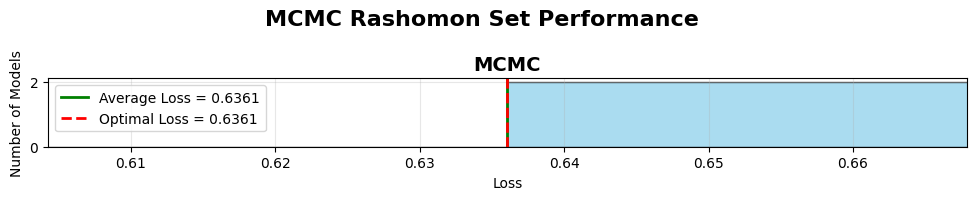

In [6]:
# Evaluate performance of models in the Rashomon set
from gam_rs_utils.utils import ModelUtils
from sklearn.metrics import accuracy_score, roc_auc_score

# Get the data
bin_X = fastsparse_data['bin_X']
y = fastsparse_data['y']
l2 = out.l2

# Compute losses for all models in the Rashomon set
logistic_losses, opt_logistic_loss = ModelUtils.get_loss(
    bin_X, y, out.w_rset, 
    loss_type='logistic', 
    w_opt=out.w_opt, 
    l2=l2
)

accuracy_losses, opt_accuracy_loss = ModelUtils.get_loss(
    bin_X, y, out.w_rset, 
    loss_type='accuracy', 
    w_opt=out.w_opt
)

# Compute predictions for all models
predictions = ModelUtils.get_predictions(bin_X, out.w_rset)  # Shape: (n_samples, n_models)

# Compute accuracy and AUC for each model
accuracies = []
aucs = []
for i in range(out.w_rset.shape[0]):
    y_pred = predictions[:, i]
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    
    # For AUC, we need probability scores, not just predictions
    logit = bin_X @ out.w_rset[i, :]
    y_proba = 1 / (1 + np.exp(-logit))  # Convert logit to probability
    auc = roc_auc_score(y, y_proba)
    aucs.append(auc)

# Print summary
print("=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Number of models in Rashomon set: {out.w_rset.shape[0]}")
print(f"\nLogistic Loss (with L2={l2}):")
print(f"  Optimal model: {opt_logistic_loss:.6f}")
print(f"  Rashomon set - Mean: {np.mean(logistic_losses):.6f}, Std: {np.std(logistic_losses):.6f}")
print(f"  Rashomon set - Min: {np.min(logistic_losses):.6f}, Max: {np.max(logistic_losses):.6f}")

print(f"\nAccuracy:")
print(f"  Optimal model: {1 - opt_accuracy_loss:.4f}")
print(f"  Rashomon set - Mean: {np.mean(accuracies):.4f}, Std: {np.std(accuracies):.4f}")
print(f"  Rashomon set - Min: {np.min(accuracies):.4f}, Max: {np.max(accuracies):.4f}")

print(f"\nAUC:")
print(f"  Rashomon set - Mean: {np.mean(aucs):.4f}, Std: {np.std(aucs):.4f}")
print(f"  Rashomon set - Min: {np.min(aucs):.4f}, Max: {np.max(aucs):.4f}")

# Visualize loss distribution
plotter = MultiPlotter(title="MCMC Rashomon Set Performance")
plotter.add_distribution(
    losses=logistic_losses,
    method_name="MCMC",
    opt_loss=opt_logistic_loss
)
fig = plotter.plot_distributions()
plt.show()
